<a href="https://colab.research.google.com/github/simon-clematide/colab-notebooks-for-teaching/blob/main/xor_Logistic_Regression_With_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The XOR Problem: From Linear Limits to Deep Learning with PyTorch

The **exclusive OR (XOR)** problem is the classic historical challenge in machine learning (Minsky & Papert, 1969).
XOR outputs `1` if and only if exactly one of its binary inputs is `1`:

| $x_1$ | $x_2$ | $y$ (XOR) |
| :---: | :---: | :-------: |
| 0     | 0     | 0         |
| 0     | 1     | 1         |
| 1     | 0     | 1         |
| 1     | 1     | 0         |

In this notebook, we explore three stages:
1. **Linear Logistic Regression:** Why gradient descent on a linear model provably fails on XOR.
2. **Feature Engineering:** How manually adding an interaction feature ($x_1 \cdot x_2$) makes the problem linearly separable.
3. **Multi-Layer Perceptron (MLP):** How a neural network with a hidden layer and non-linear activation learns the required representation automatically.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Ensure reproducibility
torch.manual_seed(42)

# XOR Dataset
X = torch.tensor([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]])
y = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

def plot_decision_boundary(model_fn, title, X_data=X, y_data=y):
    """Helper to plot the 2D decision boundary and probability surface."""
    grid_x, grid_y = torch.meshgrid(
        torch.linspace(-0.2, 1.2, 200),
        torch.linspace(-0.2, 1.2, 200),
        indexing='xy'
    )
    grid_points = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
    
    with torch.no_grad():
        preds = model_fn(grid_points).reshape(grid_x.shape)
    
    plt.figure(figsize=(5, 4))
    cs = plt.contourf(grid_x.numpy(), grid_y.numpy(), preds.numpy(), levels=20, cmap="coolwarm", alpha=0.7)
    plt.colorbar(cs, label="$P(y=1)$")
    plt.contour(grid_x.numpy(), grid_y.numpy(), preds.numpy(), levels=[0.5], colors="black", linewidths=2)
    
    # Plot the 4 XOR data points
    for pt, label in zip(X_data, y_data):
        color = "red" if label.item() == 1.0 else "blue"
        marker = "o" if label.item() == 1.0 else "s"
        plt.scatter(pt[0].item(), pt[1].item(), c=color, marker=marker, s=120, edgecolors="k", zorder=5)
        
    plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

## Part 1: Linear Logistic Regression with PyTorch Autograd

We set up a simple linear model: $\hat{y} = \sigma(\mathbf{x} \mathbf{w} + b)$.  
We use PyTorch tensors with `requires_grad=True` to observe automatic differentiation directly.

Training Linear Logistic Regression on XOR:
Epoch   0 | Loss: 0.7348 | Accuracy: 75%
Epoch  25 | Loss: 0.6939 | Accuracy: 50%
Epoch  50 | Loss: 0.6932 | Accuracy: 50%
Epoch  75 | Loss: 0.6932 | Accuracy: 25%
Epoch 100 | Loss: 0.6931 | Accuracy: 25%

Final predictions on XOR inputs:
x = [0.0, 0.0] -> target: 0, pred: 0.499
x = [0.0, 1.0] -> target: 1, pred: 0.500
x = [1.0, 0.0] -> target: 1, pred: 0.500
x = [1.0, 1.0] -> target: 0, pred: 0.501


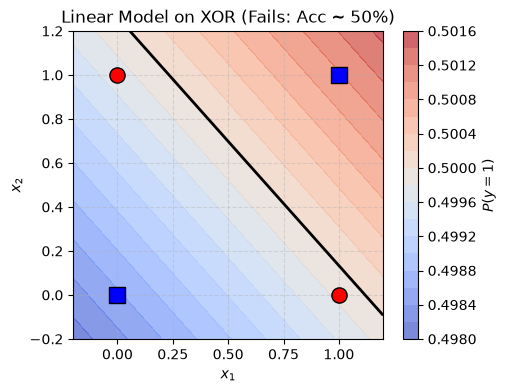

In [2]:
# Weights: 2 inputs -> 1 output, plus bias
torch.manual_seed(1)
w = torch.randn(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 1.0
losses_linear = []

print("Training Linear Logistic Regression on XOR:")
for epoch in range(101):
    # Forward pass
    logits = X @ w + b
    preds = torch.sigmoid(logits)
    
    # Binary Cross-Entropy Loss
    loss = nn.functional.binary_cross_entropy(preds, y)
    losses_linear.append(loss.item())
    
    # Backward pass (PyTorch autograd computes dloss/dw and dloss/db)
    loss.backward()
    
    # Gradient descent update step
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()
        
    if epoch % 25 == 0:
        acc = ((preds > 0.5) == y).float().mean().item() * 100
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Accuracy: {acc:.0f}%")

print("\nFinal predictions on XOR inputs:")
for i in range(4):
    print(f"x = {X[i].tolist()} -> target: {int(y[i].item())}, pred: {preds[i].item():.3f}")

# Plot the resulting linear boundary
plot_decision_boundary(lambda pts: torch.sigmoid(pts @ w + b), "Linear Model on XOR (Fails: Acc ~ 50%)")

**Observation:**  
The linear model cannot achieve better than **50% accuracy**. The loss stagnates near **0.693** ($-\ln(0.5)$), predicting $\approx 0.5$ for all points. A single straight line cannot separate the two classes.

## Part 2: Feature Engineering ($x_1 \cdot x_2$)

If the problem is not linearly separable in the raw input space $\mathbb{R}^2$, we can engineer a non-linear interaction feature:
$$\phi(\mathbf{x}) = [x_1, \; x_2, \; x_1 \cdot x_2]$$

Notice what $x_1 \cdot x_2$ does:
- For $(0,0)$, $(0,1)$, $(1,0)$, the product is `0`.
- For $(1,1)$, the product is `1`.

Now the data becomes linearly separable in $\mathbb{R}^3$!

Training Linear Model with Feature Engineering [x1, x2, x1*x2]:
Epoch   0 | Loss: 0.6931 | Accuracy: 50%
Epoch  25 | Loss: 0.3629 | Accuracy: 100%
Epoch  50 | Loss: 0.2366 | Accuracy: 100%
Epoch  75 | Loss: 0.1710 | Accuracy: 100%
Epoch 100 | Loss: 0.1323 | Accuracy: 100%

Learned Weights: [3.5541911125183105, 3.5541911125183105, -8.059551239013672] Bias: -1.5323574542999268


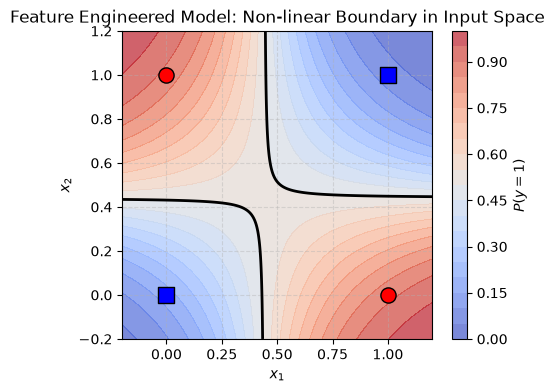

In [3]:
# Expand input with the interaction feature x1 * x2
x1_x2 = (X[:, 0] * X[:, 1]).unsqueeze(1)
X_engineered = torch.cat([X, x1_x2], dim=1)  # shape: (4, 3)

# Weights for 3 features
torch.manual_seed(1)
w_fe = torch.zeros(3, 1, requires_grad=True)
b_fe = torch.zeros(1, requires_grad=True)

lr = 2.0
losses_fe = []

print("Training Linear Model with Feature Engineering [x1, x2, x1*x2]:")
for epoch in range(101):
    logits = X_engineered @ w_fe + b_fe
    preds = torch.sigmoid(logits)
    loss = nn.functional.binary_cross_entropy(preds, y)
    losses_fe.append(loss.item())
    
    loss.backward()
    with torch.no_grad():
        w_fe -= lr * w_fe.grad
        b_fe -= lr * b_fe.grad
        w_fe.grad.zero_()
        b_fe.grad.zero_()
        
    if epoch % 25 == 0:
        acc = ((preds > 0.5) == y).float().mean().item() * 100
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Accuracy: {acc:.0f}%")

print("\nLearned Weights:", w_fe.squeeze().tolist(), "Bias:", b_fe.item())

# Decision boundary in the original 2D input space
def model_fe(pts):
    interaction = (pts[:, 0] * pts[:, 1]).unsqueeze(1)
    expanded = torch.cat([pts, interaction], dim=1)
    return torch.sigmoid(expanded @ w_fe + b_fe)

plot_decision_boundary(model_fe, "Feature Engineered Model: Non-linear Boundary in Input Space")

## Part 3: Learning the Representation with an MLP

Instead of hand-crafting features, can a neural network **learn the representation** on its own?

We build a 2-layer Feed-Forward Neural Network (Multilayer Perceptron):
- **Input layer:** 2 neurons ($x_1, x_2$)
- **Hidden layer:** 2 neurons with **ReLU** (or Sigmoid) activation
- **Output layer:** 1 neuron with Sigmoid output

Training 2-layer MLP on XOR:
Epoch   0 | Loss: 0.7138 | Accuracy: 50%
Epoch  50 | Loss: 0.0539 | Accuracy: 100%
Epoch 100 | Loss: 0.0046 | Accuracy: 100%
Epoch 150 | Loss: 0.0026 | Accuracy: 100%
Epoch 200 | Loss: 0.0018 | Accuracy: 100%
Epoch 250 | Loss: 0.0013 | Accuracy: 100%

Final MLP predictions on XOR inputs:
x = [0.0, 0.0] -> target: 0, pred: 0.0022
x = [0.0, 1.0] -> target: 1, pred: 0.9996
x = [1.0, 0.0] -> target: 1, pred: 0.9996
x = [1.0, 1.0] -> target: 0, pred: 0.0022


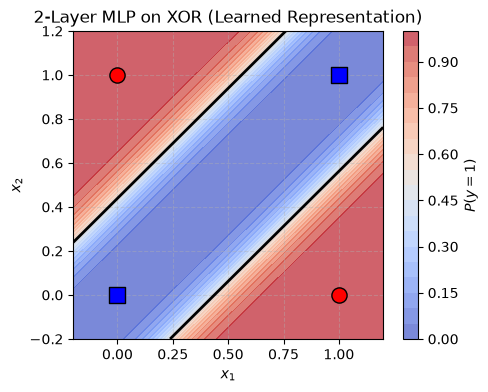

In [4]:
# Define a tiny 2-layer MLP
torch.manual_seed(18)
mlp = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
    nn.Sigmoid()
)

optimizer = torch.optim.Adam(mlp.parameters(), lr=0.1)
criterion = nn.BCELoss()

losses_mlp = []
print("Training 2-layer MLP on XOR:")
for epoch in range(251):
    optimizer.zero_grad()
    preds = mlp(X)
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()
    losses_mlp.append(loss.item())
    
    if epoch % 50 == 0:
        acc = ((preds > 0.5) == y).float().mean().item() * 100
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Accuracy: {acc:.0f}%")

print("\nFinal MLP predictions on XOR inputs:")
for i in range(4):
    print(f"x = {X[i].tolist()} -> target: {int(y[i].item())}, pred: {preds[i].item():.4f}")

plot_decision_boundary(lambda pts: mlp(pts), "2-Layer MLP on XOR (Learned Representation)")

### Peeking Inside: How the Hidden Layer Solves XOR

Why does the 2-layer network succeed where single-layer linear models fail?

Recall the two stages of the MLP:
1. **Hidden representation:** $\mathbf{h} = \text{ReLU}(\mathbf{x} \mathbf{W}_1 + \mathbf{b}_1)$, mapping each 2D input $\mathbf{x} \in \mathbb{R}^2$ to a hidden representation $\mathbf{h} \in \mathbb{R}^2$.
2. **Linear classification:** $\hat{y} = \sigma(\mathbf{h} \mathbf{w}_2 + b_2)$.

Notice that the final layer is **purely linear**! A linear model can only draw a straight separating line. Therefore, the network can only solve XOR if the hidden layer has successfully **transformed the representation into a space where XOR becomes linearly separable**.

Let us extract the hidden vectors $\mathbf{h}$ for each of the four XOR input points and plot the decision boundary in the $(h_1, h_2)$ plane.

Mapping from Input Space (x1, x2) to Hidden Space (h1, h2):
---------------------------------------------------------------
Input x         Target y   Hidden h = [h1, h2]       Pred y_hat
[0.0, 0.0]      0          [0.000, 0.000]            0.0022    
[0.0, 1.0]      1          [0.000, 3.096]            0.9996    
[1.0, 0.0]      1          [3.615, 0.000]            0.9996    
[1.0, 1.0]      0          [0.000, 0.000]            0.0022    


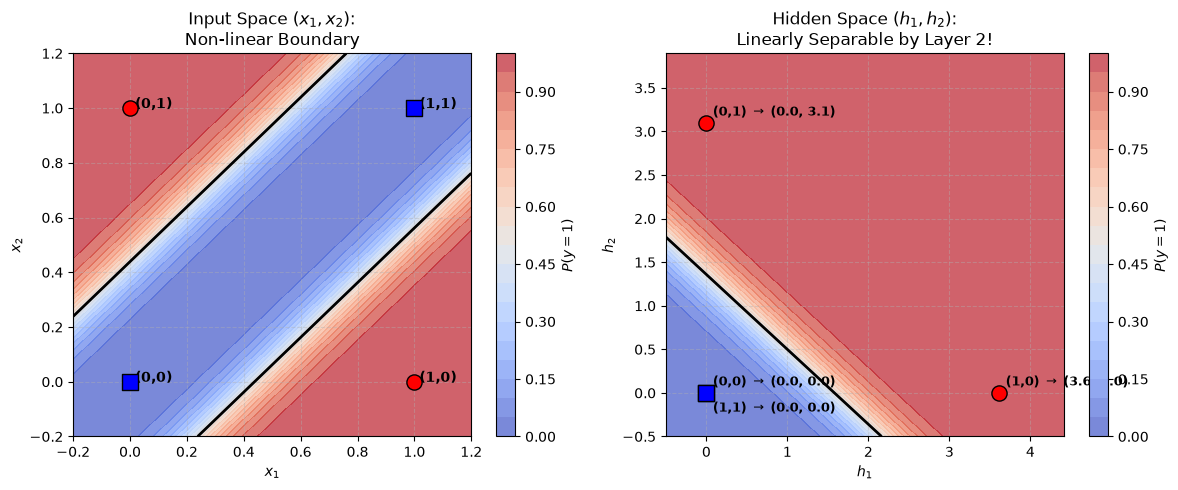

In [5]:
# Extract the hidden layer (first Linear + ReLU) and output layer
hidden_submodel = mlp[0:2]  # Linear(2, 2) -> ReLU()
output_layer = mlp[2:]      # Linear(2, 1) -> Sigmoid()

with torch.no_grad():
    H = hidden_submodel(X)

print("Mapping from Input Space (x1, x2) to Hidden Space (h1, h2):")
print("-" * 63)
print(f"{'Input x':<15} {'Target y':<10} {'Hidden h = [h1, h2]':<25} {'Pred y_hat':<10}")
for i in range(4):
    x_str = str(X[i].tolist())
    t_val = int(y[i].item())
    h_str = f"[{H[i,0].item():.3f}, {H[i,1].item():.3f}]"
    p_val = f"{preds[i].item():.4f}"
    print(f"{x_str:<15} {t_val:<10} {h_str:<25} {p_val:<10}")

# Side-by-side visualization: Input Space vs. Hidden Representation Space
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Input space (x1, x2) with non-linear decision boundary
grid_x, grid_y = torch.meshgrid(
    torch.linspace(-0.2, 1.2, 200),
    torch.linspace(-0.2, 1.2, 200),
    indexing='xy'
)
grid_points = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
with torch.no_grad():
    preds_grid = mlp(grid_points).reshape(grid_x.shape)

cs0 = axes[0].contourf(grid_x.numpy(), grid_y.numpy(), preds_grid.numpy(), levels=20, cmap="coolwarm", alpha=0.7)
plt.colorbar(cs0, ax=axes[0], label="$P(y=1)$")
axes[0].contour(grid_x.numpy(), grid_y.numpy(), preds_grid.numpy(), levels=[0.5], colors="black", linewidths=2)
for pt, label, name in zip(X, y, ["(0,0)", "(0,1)", "(1,0)", "(1,1)"]):
    color = "red" if label.item() == 1.0 else "blue"
    marker = "o" if label.item() == 1.0 else "s"
    axes[0].scatter(pt[0].item(), pt[1].item(), c=color, marker=marker, s=120, edgecolors="k", zorder=5)
    axes[0].annotate(f" {name}", (pt[0].item(), pt[1].item()), fontsize=10, fontweight="bold")
axes[0].set_title("Input Space $(x_1, x_2)$:\nNon-linear Boundary")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].grid(True, linestyle="--", alpha=0.4)

# 2. Hidden feature space (h1, h2) with linear decision boundary from Layer 2
h_max1 = max(float(H[:, 0].max().item()), 1.0) + 0.8
h_max2 = max(float(H[:, 1].max().item()), 1.0) + 0.8
grid_h1, grid_h2 = torch.meshgrid(
    torch.linspace(-0.5, h_max1, 200),
    torch.linspace(-0.5, h_max2, 200),
    indexing='xy'
)
grid_h = torch.stack([grid_h1.flatten(), grid_h2.flatten()], dim=1)
with torch.no_grad():
    preds_h = output_layer(grid_h).reshape(grid_h1.shape)

cs1 = axes[1].contourf(grid_h1.numpy(), grid_h2.numpy(), preds_h.numpy(), levels=20, cmap="coolwarm", alpha=0.7)
plt.colorbar(cs1, ax=axes[1], label="$P(y=1)$")
axes[1].contour(grid_h1.numpy(), grid_h2.numpy(), preds_h.numpy(), levels=[0.5], colors="black", linewidths=2)

# Plot the mapped points in hidden space
for i, (pt, label, name) in enumerate(zip(H, y, ["(0,0)", "(0,1)", "(1,0)", "(1,1)"])):
    color = "red" if label.item() == 1.0 else "blue"
    marker = "o" if label.item() == 1.0 else "s"
    axes[1].scatter(pt[0].item(), pt[1].item(), c=color, marker=marker, s=120, edgecolors="k", zorder=5)
    # Offset annotations to prevent overlap at (0, 0)
    offset = (0.08, 0.08) if i != 3 else (0.08, -0.22)
    axes[1].annotate(f"{name} $\\to$ ({pt[0]:.1f}, {pt[1]:.1f})", 
                    (pt[0].item() + offset[0], pt[1].item() + offset[1]), 
                    fontsize=9, fontweight="bold")

axes[1].set_title("Hidden Space $(h_1, h_2)$:\nLinearly Separable by Layer 2!")
axes[1].set_xlabel("$h_1$")
axes[1].set_ylabel("$h_2$")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Geometric Insight:**
- The ReLU activation function allows the network to **'fold' the input space**.
- Look at what happened to the two negative class points $(0,0)$ and $(1,1)$:
  - In the original input space, they were diagonal from each other, making linear separation impossible.
  - In the learned hidden space $(h_1, h_2)$, the network **collapsed both $(0,0)$ and $(1,1)$ onto the origin $(0, 0)$**!
- Meanwhile, the two positive class points $(0,1)$ and $(1,0)$ were projected along the positive coordinate axes.
- Now, the second layer only needs to draw a **single straight line** (linear decision boundary) to separate the origin (class `0`) from the positive quadrant (class `1`).
- **This is Representation Learning:** rather than requiring a human to craft features (as we did in Part 2), the neural network learned the optimal coordinate transformation end-to-end via gradient descent.

## Summary & Conceptual Takeaways

1. **Linear Limits:** A single-layer linear model cannot solve XOR because the two classes cannot be separated by a hyper-plane.
2. **Feature Engineering vs. Deep Learning:**
   - In classical ML, we manually engineer transformations ($x_1 \cdot x_2$).
   - In deep learning, hidden layers equipped with non-linear activation functions (ReLU, Sigmoid) learn to transform the input space into a new coordinate system where the data *becomes* linearly separable.
3. **Autodiff in PyTorch:** The training loop remains identical across linear models and deep neural networks: `forward() -> loss -> loss.backward() -> step()`.